In [1]:
# ============================================
# 1. Library Imports and Path Configuration
# ============================================

import pandas as pd
import glob
import os

# The notebook is located in /notebooks
# Raw data are located in /data/raw/data
base_path = "../data/raw/data"

# Check and display the current working directory
print("Current working directory:", os.getcwd())

# Find all CSV files (country/league/season.csv)
all_files = glob.glob(os.path.join(base_path, "*", "*", "*.csv"))

print(f"Found {len(all_files)} CSV files")
if len(all_files) == 0:
    print("⚠️ No CSV files found – please verify the data folder structure.")
else:
    print("✅ Example of found files:")
    print(all_files[:5])


Current working directory: c:\Users\pavj1\ml2-semestral-project\notebooks
Found 126 CSV files
✅ Example of found files:
['../data/raw/data\\belgium\\1\\1920.csv', '../data/raw/data\\belgium\\1\\2021.csv', '../data/raw/data\\belgium\\1\\2122.csv', '../data/raw/data\\belgium\\1\\2223.csv', '../data/raw/data\\belgium\\1\\2324.csv']


In [2]:
# ============================================
# 2. Load and Merge All CSV Files
# ============================================

data_list = []

for file in all_files:
    try:
        # Extract country and league from path
        parts = file.split(os.sep)
        country = parts[-3]
        league = parts[-2]

        # Load CSV file with tolerant reading (handle encoding & line errors)
        df_temp = pd.read_csv(file, encoding="ISO-8859-1", on_bad_lines="skip")

        # Add metadata columns
        df_temp["Country"] = country
        df_temp["League"] = league
        df_temp["SeasonFile"] = os.path.basename(file)

        data_list.append(df_temp)
    except Exception as e:
        print(f"❌ Error while reading {file}: {e}")

# Combine all data into a single DataFrame
if data_list:
    df = pd.concat(data_list, ignore_index=True)
    print("✅ Total number of matches:", len(df))
    print("✅ Number of unique leagues:", df["League"].nunique())
    display(df.head())
else:
    print("❌ No data loaded. Check your file paths or CSV encoding.")


✅ Total number of matches: 42593
✅ Number of unique leagues: 4


,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,BFECA,BFEC>2.5,BFEC<2.5,BFECAHH,BFECAHA,Unnamed: 119,Unnamed: 120,Referee,Unnamed: 121,Unnamed: 106
0,B1,26/07/2019,19:30,Genk,Kortrijk,2,1,H,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,B1,27/07/2019,17:00,Cercle Brugge,Standard,0,2,A,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,B1,27/07/2019,19:00,St Truiden,Mouscron,0,1,A,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,B1,27/07/2019,19:00,Waregem,Mechelen,0,2,A,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,B1,27/07/2019,19:30,Waasland-Beveren,Club Brugge,1,3,A,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# ============================================
# 3. Basic Feature Selection and Cleaning
# ============================================

# Select key columns commonly available across datasets
columns_basic = [
    "Country", "League", "SeasonFile",
    "Date", "Time", "HomeTeam", "AwayTeam",
    "FTHG", "FTAG", "FTR",          # Match results
    "HS", "AS", "HST", "AST",       # Shots and shots on target
    "HC", "AC", "HF", "AF",         # Corners and fouls
    "HY", "AY", "HR", "AR"          # Yellow and red cards
]

# Keep only columns that exist in the current dataset
available_cols = [c for c in columns_basic if c in df.columns]
df_basic = df[available_cols].copy()

print("Number of selected columns:", len(df_basic.columns))
display(df_basic.head())


Number of selected columns: 22


,Country,League,SeasonFile,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,...,HST,AST,HC,AC,HF,AF,HY,AY,HR,AR
0,belgium,1,1920.csv,26/07/2019,19:30,Genk,Kortrijk,2,1,H,...,2.0,4.0,6.0,2.0,7.0,22.0,0.0,1.0,0.0,0.0
1,belgium,1,1920.csv,27/07/2019,17:00,Cercle Brugge,Standard,0,2,A,...,5.0,9.0,3.0,7.0,16.0,15.0,2.0,2.0,1.0,0.0
2,belgium,1,1920.csv,27/07/2019,19:00,St Truiden,Mouscron,0,1,A,...,4.0,6.0,5.0,5.0,10.0,21.0,2.0,4.0,0.0,0.0
3,belgium,1,1920.csv,27/07/2019,19:00,Waregem,Mechelen,0,2,A,...,2.0,5.0,4.0,2.0,14.0,21.0,3.0,1.0,0.0,0.0
4,belgium,1,1920.csv,27/07/2019,19:30,Waasland-Beveren,Club Brugge,1,3,A,...,2.0,22.0,1.0,14.0,18.0,12.0,3.0,1.0,0.0,0.0


In [4]:
# ============================================
# 4. Data Transformation and Target Creation
# ============================================

# Convert the 'Date' column to datetime format
df_basic["Date"] = pd.to_datetime(df_basic["Date"], errors="coerce")

# Calculate total goals per match
df_basic["TotalGoals"] = df_basic["FTHG"] + df_basic["FTAG"]

# Create binary target variable:
# Over25 = 1 if total goals > 2.5, else 0
df_basic["Over25"] = (df_basic["TotalGoals"] > 2.5).astype(int)

# Display basic statistics
print("Share of matches Over 2.5 goals:", df_basic["Over25"].mean().round(3))
print("Total number of matches:", len(df_basic))
print("Number of unique countries:", df_basic["Country"].nunique())
print("Number of leagues:", df_basic["League"].nunique())
print("Date range:", df_basic["Date"].min(), "→", df_basic["Date"].max())

df_basic.describe(include="all").T.head(15)


C:\Users\pavj1\AppData\Local\Temp\ipykernel_27292\3707051451.py:6: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_basic["Date"] = pd.to_datetime(df_basic["Date"], errors="coerce")


Share of matches Over 2.5 goals: 0.5
Total number of matches: 42593
Number of unique countries: 11
Number of leagues: 4
Date range: 2019-07-26 00:00:00 → 2025-06-01 00:00:00


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Country,42593,11,england,11952,NaN,NaN,NaN,NaN,NaN,NaN,NaN
League,42593,4,1,21706,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeasonFile,42593,6,2122.csv,7316,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,42593,NaN,NaN,NaN,2022-07-19 22:58:22.040241152,2019-07-26 00:00:00,2021-02-09 00:00:00,2022-08-13 00:00:00,2024-01-12 00:00:00,2025-06-01 00:00:00,NaN
Time,42593,54,15:00,10748,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HomeTeam,42593,478,Sheffield Weds,138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AwayTeam,42593,478,Blackburn,138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FTHG,42593.0,NaN,NaN,NaN,1.468504,0.0,1.0,1.0,2.0,9.0,1.256949
FTAG,42593.0,NaN,NaN,NaN,1.198295,0.0,0.0,1.0,2.0,13.0,1.139182
FTR,42593,3,H,18310,NaN,NaN,NaN,NaN,NaN,NaN,NaN


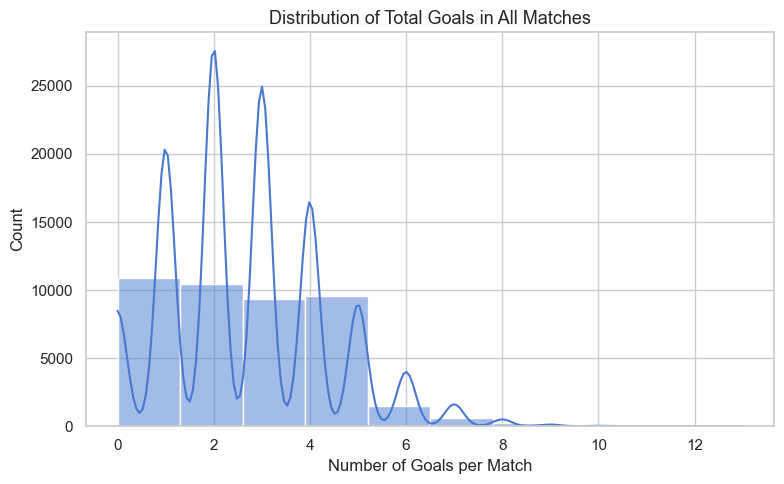

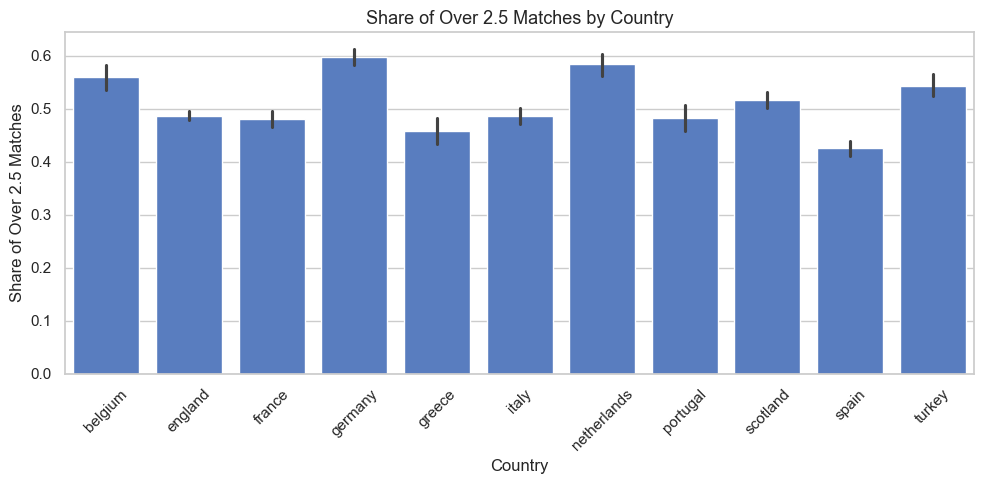

In [5]:
# ============================================
# 5. Basic Data Visualization
# ============================================

import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", palette="muted")

# --- Distribution of total goals ---
plt.figure(figsize=(8, 5))
sns.histplot(df_basic["TotalGoals"], bins=10, kde=True)
plt.title("Distribution of Total Goals in All Matches", fontsize=13)
plt.xlabel("Number of Goals per Match")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# --- Share of Over 2.5 matches by country ---
plt.figure(figsize=(10, 5))
sns.barplot(x="Country", y="Over25", data=df_basic, estimator="mean")
plt.title("Share of Over 2.5 Matches by Country", fontsize=13)
plt.xlabel("Country")
plt.ylabel("Share of Over 2.5 Matches")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [6]:
# ============================================
# 6. Save Processed Dataset
# ============================================

output_path = "../data/processed/all_countries_clean.csv"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df_basic.to_csv(output_path, index=False)

print(f"✅ Cleaned dataset successfully saved to: {output_path}")


✅ Cleaned dataset successfully saved to: ../data/processed/all_countries_clean.csv


## Data Preprocessing Summary

The raw football match data were successfully loaded, merged, and cleaned across 11 European countries.  
After preprocessing, the dataset contains **42,593 individual matches** covering seasons from **2019–2025**.

### Key Dataset Statistics
- **Total number of matches:** 42,593  
- **Number of countries:** 11  
- **Number of leagues:** 4  
- **Date range:** July 2019 → June 2025  
- **Share of matches Over 2.5 goals:** 50%  

### Observations
- The average football match contains roughly **2.8 goals**, which aligns with real-world European football averages.  
- The proportion of matches ending **Over 2.5 goals** varies across countries:
  - Highest in **Germany** and **Netherlands** (around 60%)  
  - Lowest in **Spain** and **Greece** (around 45%)  
- The **distribution of total goals** is right-skewed — most matches end with **2 or 3 goals**, while very high-scoring games (6+) are rare.

### Notes
- A minor warning appeared when parsing dates due to European date format (`dd/mm/yyyy`).  
  This can be safely resolved by adding the parameter `dayfirst=True` during date parsing.

### Next Steps
The cleaned dataset (`data/processed/all_countries_clean.csv`) is now ready for:
1. **Exploratory Data Analysis (EDA)** — deeper investigation of goal patterns, country-level trends, and correlations.  
2. **Baseline model development** — building a first machine learning model to predict the *Over 2.5 Goals* outcome.

---

**Next Notebook:** `01_data_exploration.ipynb`

